# Data Cleaning & EDA

In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pandas as pd

In [4]:
df_main = pd.read_csv("Financial_Data.csv")
df_index = df_main['Date']
df_main.drop(columns=['Date'], inplace=True)
df_main = df_main.astype(float)
df_main.index = df_index
df_main

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,,,,,,
2000-08-30,33.400002,273.899994,8.264154,13.620219,20.652037,1502.589966,5.800,4.1,172.700,6.50,-0.43,17.69,6.28
2000-08-31,33.099998,278.299988,8.232369,13.972992,21.059486,1517.680054,5.729,4.1,172.700,6.50,-0.45,16.84,6.43
2000-09-01,33.380001,277.000000,8.315806,13.742926,21.071123,1520.770020,5.675,3.9,173.600,6.52,-0.41,17.53,6.48
2000-09-04,33.380001,277.000000,8.315806,13.742926,21.071123,1520.770020,5.675,3.9,173.600,6.52,-0.41,17.53,6.49
2000-09-05,33.799999,275.799988,8.315806,13.911640,20.593821,1507.079956,5.683,3.9,173.600,6.52,-0.40,19.82,6.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,74.559998,5107.399902,56.520000,51.209999,137.500000,6816.629883,4.056,4.4,326.588,3.64,0.55,23.57,3.08
2026-03-04,74.660004,5120.200195,56.189999,51.500000,139.839996,6869.500000,4.080,4.4,326.588,3.64,0.55,21.15,2.97
2026-03-05,81.010002,5065.299805,56.480000,51.230000,140.179993,6830.709961,4.146,4.4,326.588,3.64,0.56,23.75,3.00


In [5]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)





#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
df_transform.head()

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,,,,,,
2000-08-31,-0.009023,0.015937,-0.003854,0.025571,0.019537,0.009993,-0.012317,0.0,0.000000,0.00,-0.02,-0.85,0.15
2000-09-01,0.008424,-0.004682,0.010084,-0.016602,0.000552,0.002034,-0.009470,-0.2,0.005198,0.02,0.04,0.69,0.05
2000-09-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.00,0.00,0.01
2000-09-05,0.012504,-0.004342,0.000000,0.012202,-0.022912,-0.009043,0.001409,0.0,0.000000,0.00,0.01,2.29,-0.08
2000-09-06,0.033458,-0.005818,0.021740,0.007688,-0.025767,-0.009889,0.005090,0.0,0.000000,0.00,0.01,0.97,-0.04


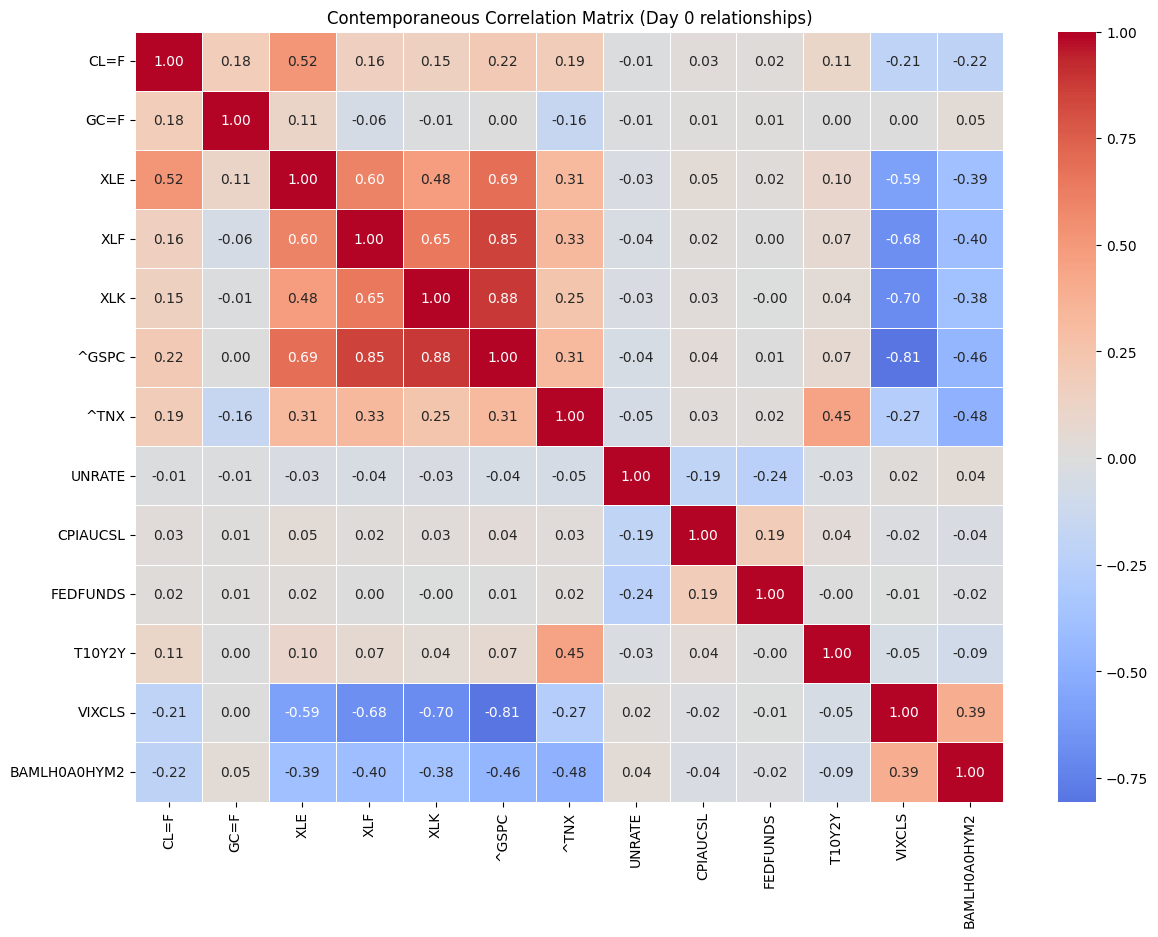

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_transform.corr(), 
    annot=True,       # Show the numbers
    cmap='coolwarm',  # Blue (Neg) to Red (Pos)
    center=0,         # Set 0 as the middle (white)
    fmt=".2f",        # 2 decimal places
    linewidths=0.5
)
plt.title("Contemporaneous Correlation Matrix (Day 0 relationships)")
plt.show()

# Analysis

In [8]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

In [9]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## Time Lag Optimization (Elbow Analysis)

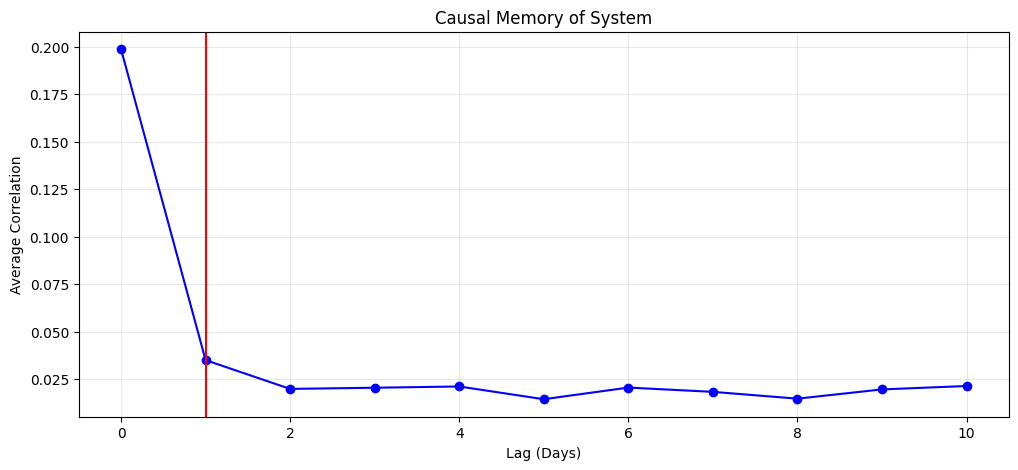

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

vals = df_transform.values
var_names = df_transform.columns.tolist()

# tigramite dataframe, mapping data to time indices for tau optimization later
dataframe = dp.DataFrame(vals, datatime=np.arange(len(vals)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

data_source = df_transform
vals = StandardScaler().fit_transform(data_source.values)
var_names = df_transform.columns.tolist()
T_num = len(vals)

dataframe = dp.DataFrame(vals, datatime=np.arange(T_num), var_names=var_names)
#initilize PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

#tau optimization up to tau=10
tau_results = pcmci.get_lagged_dependencies(tau_max=10, val_only=False)
val_matrix = tau_results['val_matrix']

#avg corrlation for each tau without self dependencies
avg_decays = []
n_vars = val_matrix.shape[0]
for tau in range(11):
    lag_matrix = np.abs(val_matrix[:, :, tau])
    np.fill_diagonal(lag_matrix, 0)
    avg_decays.append(np.sum(lag_matrix) / (n_vars * (n_vars - 1)))


plt.figure(figsize=(12, 5))
plt.title('Causal Memory of System')
plt.plot(range(11), avg_decays, marker='o', color='blue')
plt.xlabel('Lag (Days)')
plt.ylabel('Average Correlation')
plt.axvline(x=1, color='red')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
optimal_tau = 3

## Optimizing Alpha

In [13]:
# optimizing alpha
alphas = [0.001, 0.01, 0.05, 0.1]
best_bic = float('inf')
best_alpha = None
results_dict = {}

for alpha in alphas:
    # RUN SPECIALIZED MODEL
    # tau_min=1 removes instant noise
    results = pcmci.run_pcmci(tau_min=1, tau_max=optimal_tau, pc_alpha=alpha)
    
    # calc BIC (Bayesian Information Criterion)
    graph = results['graph']
    n_edges = np.count_nonzero(graph != "")
    strength_sum = np.sum(np.abs(results['val_matrix'][graph != ""]))
    
    T_eff = T_num - optimal_tau
    
    # BIC: Penalty for Edges - Reward for Fit
    bic = (n_edges * np.log(T_eff)) - (2 * strength_sum * T_eff)
    
    results_dict[alpha] = results
    
    print(f"Alpha: {alpha:<5} | Edges: {n_edges:<3} | BIC: {bic:.0f}")
    
    if bic < best_bic:
        best_bic = bic
        best_alpha = alpha

print(f"Specialized Alpha: {best_alpha} (Lowest BIC)")

Alpha: 0.001 | Edges: 154 | BIC: -96890
Alpha: 0.01  | Edges: 141 | BIC: -83173
Alpha: 0.05  | Edges: 146 | BIC: -86629
Alpha: 0.1   | Edges: 139 | BIC: -82420
Specialized Alpha: 0.001 (Lowest BIC)


## Visualizing Causal Graphs

In [14]:


split_idx = int(len(vals) * 0.8)
train_vals = vals[:split_idx]
test_vals = vals[split_idx:]

# splitting training and testing based on time series data
train_df = dp.DataFrame(train_vals, datatime=np.arange(len(train_vals)), var_names = var_names)
test_df = dp.DataFrame(test_vals, datatime=np.arange(len(test_vals)), var_names = var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_df, cond_ind_test=parcorr, verbosity=0)

baseline = pcmci.run_pcmci(tau_min=1, tau_max=5, pc_alpha=0.05)
specialized = pcmci.run_pcmci(tau_min=1, tau_max=1, pc_alpha=0.1)

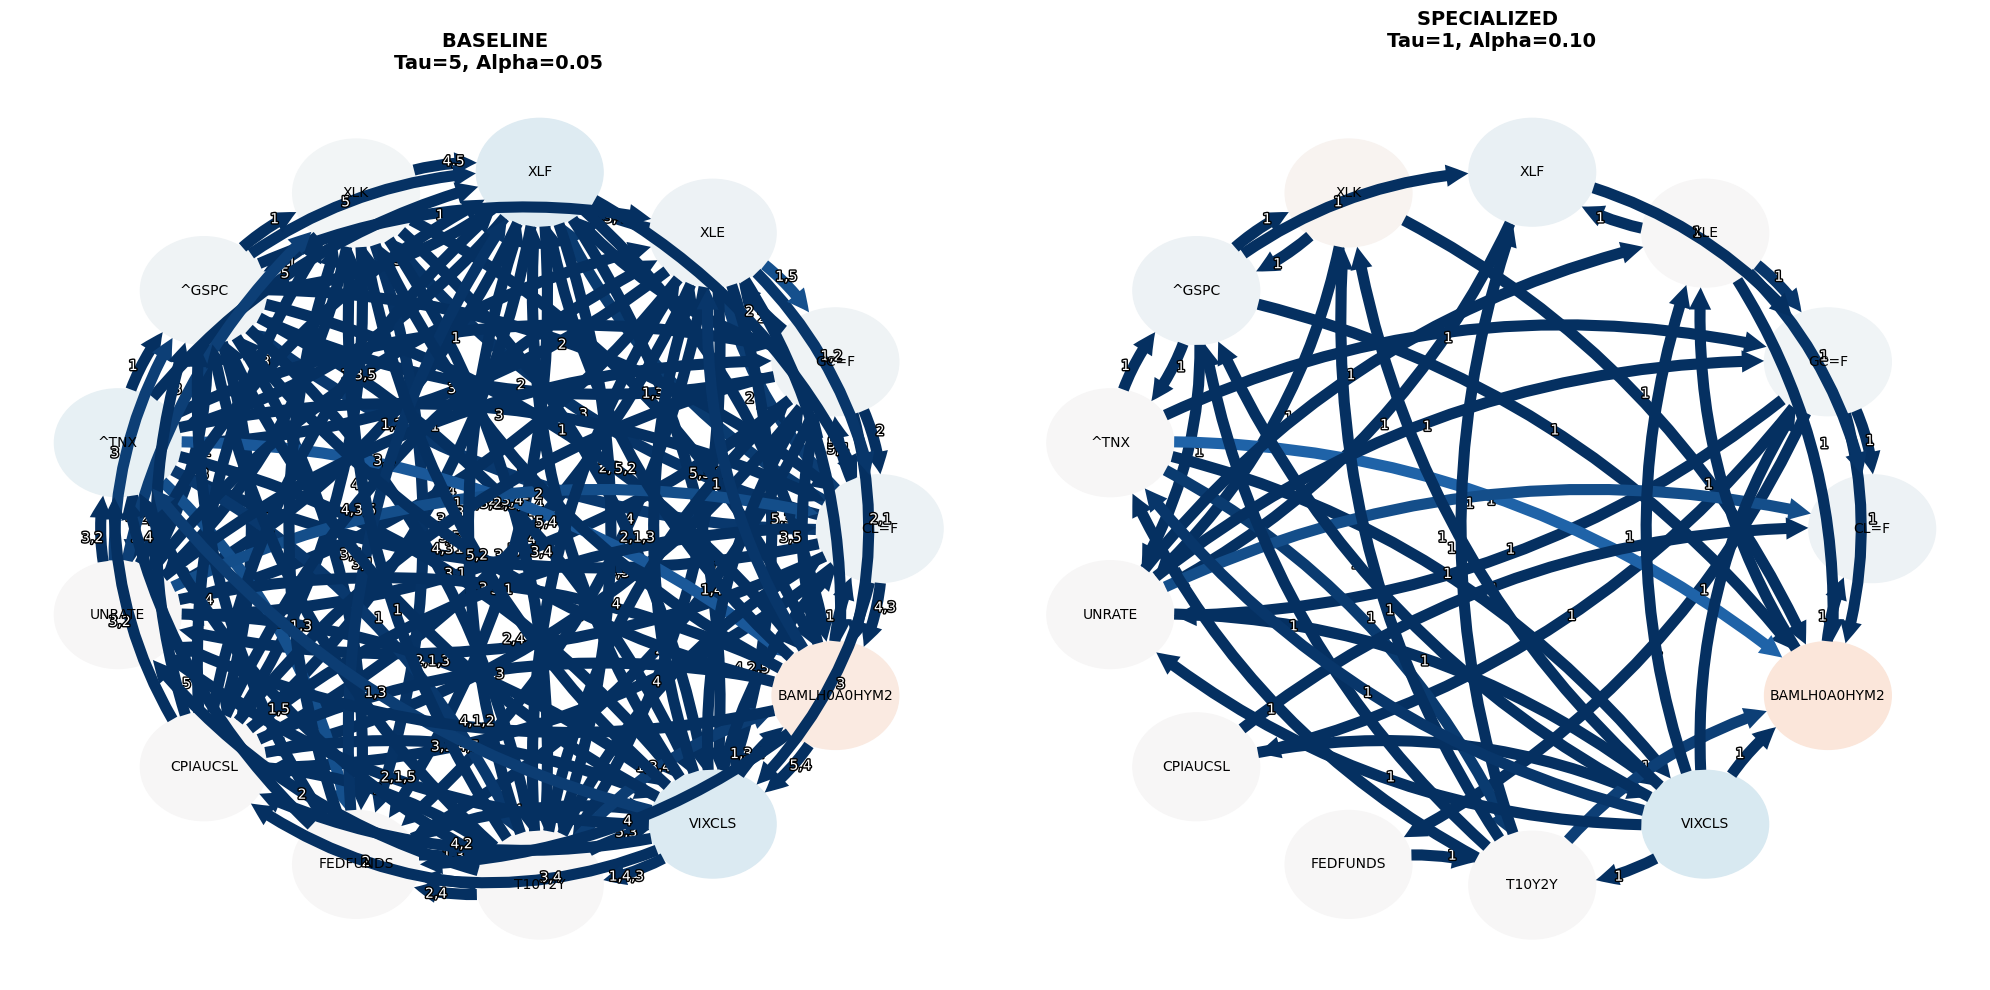

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# plot baseline
tp.plot_graph(
    val_matrix=baseline['val_matrix'],
    graph=baseline['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[0]) 
)
axes[0].set_title(f"BASELINE \nTau=5, Alpha=0.05", fontsize=14, fontweight='bold')

# Plot Specialized
tp.plot_graph(
    val_matrix=specialized['val_matrix'],
    graph=specialized['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[1])
)
axes[1].set_title(f"SPECIALIZED \nTau=1, Alpha=0.10\n", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
